# OCHEM → SDF с температурами кипения для ML

**Цель.** Подготовить датасет `(структура молекулы, Tb)` из OCHEM
(`selected_records.sdf.zip.sdf`) для последующего объединения с chemeo и PubChem
и обучения ML-модели.

## Что нам дали в исходнике

29 056 записей в SDF, у каждой:
- `SMILES`, `CASRN`, `NAME`, `MOLECULEID`, `RECORDID` — идентификация
- `INTRODUCER`, `MODIFIER`, `ARTICLEID`, `PAGE` — провенанс данных
- `Boiling Point` — исходное значение (часто диапазон вроде "105.0 - 108.0")
- `Boiling Point {measured, converted}` — **уже сконвертированное число в °C**
- `UNIT {Boiling Point}` — везде `Celsius`
- `Pressure` + `UNIT {Pressure}` — давление с явной единицей (atm, mm Hg, Pa, kPa, Torr, hPa)
- `COMMENTS` — пояснения автора (например "Pressure was not indicated. It was assumed to be 1 atm.")

Это уже **на порядок чище**, чем PubChem-аннотации. Никаких regex-парсеров,
никаких °F→°C — только унификация давления и стандартная пост-обработка.

## Пайплайн

1. **Загрузка SDF** в pandas DataFrame.
2. **Унификация давления** в атмосферы (atm = mm Hg / 760 = Pa / 101325 = kPa / 101.325 = Torr / 760 = hPa / 1013.25).
3. **Физический фильтр**: Tb ∈ [−200, 700] °C, P ∈ [0.001, 100] атм.
4. **Запись промежуточного SDF** (`ochem_raw_clean.sdf`) с унифицированными метаданными.
5. **Стандартизация** через `chython` (канонизация, изотопы, координационные связи, соли, нейтрализация, отброс многокомпонентных и радикалов).
6. **Дедупликация по InChI** с проверкой согласованности (`max_spread = 20 °C`).
7. **EDA**: дашборд, sanity-check, поиск выбросов.
8. **Финальная фильтрация**: только записи при P ≈ 1 атм, 3σ-чистка. Сохраняем `ochem_nbp_ml_ready_pure.sdf`.


In [71]:
# 1. Импорты
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, RDLogger
RDLogger.DisableLog("rdApp.*")
from rdkit.Chem import Descriptors, rdMolDescriptors, SDWriter
from rdkit.Chem.inchi import MolToInchi, MolToInchiKey

from chython.files import SDFRead, SDFWrite

SDF_IN = "selected_records.sdf.zip.sdf"
print("Будем читать:", SDF_IN, "размер:", os.path.getsize(SDF_IN), "байт")


Будем читать: selected_records.sdf.zip.sdf размер: 44036767 байт


### Шаг 1. Загрузка SDF в DataFrame

Берём только нужные поля: SMILES, CAS, имя, ID, Tb (уже сконвертированный), давление + единица, провенанс.

In [72]:
# 2. Загрузка SDF в DataFrame
rows = []
for m in Chem.SDMolSupplier(SDF_IN, removeHs=False):
    if m is None:
        continue
    def gp(k, default=None):
        return m.GetProp(k) if m.HasProp(k) else default
    rows.append({
        "smiles":   gp("SMILES"),
        "cas":      gp("CASRN"),
        "name":     gp("NAME"),
        "record":   gp("RECORDID"),
        "mol_id":   gp("MOLECULEID"),
        "article":  gp("ARTICLEID"),
        "Tb_raw":   gp("Boiling Point"),
        "Tb_C":     gp("Boiling Point {measured, converted}"),
        "P_raw":    gp("Pressure"),
        "P_unit":   gp("UNIT {Pressure}"),
        "comments": gp("COMMENTS"),
    })

df = pd.DataFrame(rows)
df["Tb_C"] = pd.to_numeric(df["Tb_C"], errors="coerce")
df["P_raw"] = pd.to_numeric(df["P_raw"], errors="coerce")
print("Всего записей:", len(df))
print("С валидной Tb:", df["Tb_C"].notna().sum())
print("С валидным P:", df["P_raw"].notna().sum())
print()
print("Распределение единиц давления:")
print(df["P_unit"].value_counts(dropna=False))
df.head()


Всего записей: 29050
С валидной Tb: 29050
С валидным P: 22574

Распределение единиц давления:
P_unit
atm      20781
mm Hg     8217
Pa          46
Torr         3
kPa          2
hPa          1
Name: count, dtype: int64


,smiles,cas,name,record,mol_id,article,Tb_raw,Tb_C,P_raw,P_unit,comments
0,C=CCOC(=O)C=CC1=CC=CC=C1,1866-31-5,FRA-003; Allyl cinnamate,R33100,M5463,A2021,105.0 - 108.0,106.5,1.0,atm,Pressure was not indicated. It was assumed to ...
1,CC(C)(C)C(O)C(CC1=CC=C(Cl)C=C1)N1C=NC=N1,76738-62-0,Paclobutrazol,R38932,M15133,A2073,383.5 - 384.5,384.0,1.0,atm,"Method: EEC method A 2. Cuthbert, J.E., Mullee..."
2,[NH4+].[O-]C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(...,3825-26-1,"APFO; PerFluoro Octanoate, ammonium salt",R39232,M14606,A2573,130.0,130.0,1.0,atm,Pressure was not provided. Assumed to be 1 atm.
3,[NH4+].[O-]C(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(...,3825-26-1,"APFO; PerFluoro Octanoate, ammonium salt",R39233,M14606,A2575,203.0,203.0,760.0,mm Hg,NaN
4,OC(=O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(C(F)(F)...,15166-06-0,CF3(CF3)CF(CF2)4COOH; Isomer of PFOA,R39234,M15268,A2558,189.0,189.0,760.0,mm Hg,NaN


### Шаг 2. Унификация давления

Конверсия в атмосферы:
- `atm` — как есть
- `mm Hg`, `Torr` — делим на 760
- `Pa` — делим на 101 325
- `kPa` — делим на 101.325
- `hPa` — делим на 1013.25

In [73]:
# 3. Унификация давления в атм
P_TO_ATM = {
    "atm":   1.0,
    "mm Hg": 1.0 / 760.0,
    "Torr":  1.0 / 760.0,
    "Torr ": 1.0 / 760.0,    # с лишним пробелом в исходных данных
    "Pa":    1.0 / 101325.0,
    "kPa":   1.0 / 101.325,
    "hPa":   1.0 / 1013.25,
}

def to_atm(row):
    p, u = row["P_raw"], row["P_unit"]
    if pd.isna(p) or u is None:
        return np.nan
    k = P_TO_ATM.get(u)
    if k is None:
        return np.nan
    return float(p) * k

df["Pressure_Atm"] = df.apply(to_atm, axis=1)
df["Temperature_Celsius"] = df["Tb_C"]

print("Диапазон Pressure_Atm:", df["Pressure_Atm"].min(), "...", df["Pressure_Atm"].max())
print("Диапазон Tb (°C):     ", df["Temperature_Celsius"].min(), "...", df["Temperature_Celsius"].max())
print()
print("Сколько записей при ~1 атм (0.95..1.05):", df["Pressure_Atm"].between(0.95, 1.05).sum())
print("Сколько с известным, но не 1 атм:        ", ((df["Pressure_Atm"].notna()) & ~df["Pressure_Atm"].between(0.95, 1.05)).sum())
print("Сколько с NaN давлением:                  ", df["Pressure_Atm"].isna().sum())


Диапазон Pressure_Atm: 0.0 ... 1.9736842105263157
Диапазон Tb (°C):      -161.5 ... 5660.0

Сколько записей при ~1 атм (0.95..1.05): 19815
Сколько с известным, но не 1 атм:         2759
Сколько с NaN давлением:                   6476


### Шаг 3. Физический фильтр + фильтр по давлению

Отсекаем явный мусор и оставляем **только измерения при P ≈ 1 атм** (нормальные точки кипения).

Почему фильтр по давлению идёт ДО дедупликации:
- если у бензола в OCHEM есть запись «80 °C @ 1 атм» и «12 °C @ 5 mm Hg», их усреднение даёт 46 °C — это **полный мусор**;
- Tb при пониженном давлении — это **другая физическая величина**, её нельзя ни усреднять с NBP, ни сравнивать с chemeo/PubChem;
- единственный честный путь объединить три базы — приводить всё к одному давлению (1 атм) и дедуплицировать после.

Критерии фильтра:
- `Tb ∈ [−200, 700] °C` — физически возможные температуры кипения.
- `Pressure_Atm ∈ [0.95, 1.05]` — окно вокруг 1 атм (учитываем округление и небольшие литературные погрешности).
- SMILES должен парситься RDKit-ом, InChI генерироваться.


In [74]:
# 4. Физический фильтр (Tb, P ~ 1 атм) + проверка SMILES
n_before = len(df)
mask_tb   = df["Temperature_Celsius"].between(-200, 700)
mask_p    = df["Pressure_Atm"].between(0.95, 1.05)
mask_smi  = df["smiles"].notna()
df_phys = df.loc[mask_tb & mask_p & mask_smi].copy()
print(f"Исходно записей:               {n_before}")
print(f"  -- проходят Tb-фильтр:        {int(mask_tb.sum())}")
print(f"  -- из них P ~ 1 атм:          {int((mask_tb & mask_p).sum())}")
print(f"  -- из них с валидным SMILES:  {len(df_phys)}")

# Проверяем парсинг SMILES через RDKit (заодно канонизируем)
def canon_smiles(s):
    if not isinstance(s, str): return None
    m = Chem.MolFromSmiles(s)
    if m is None: return None
    return Chem.MolToSmiles(m)

df_phys["canon_smiles"] = df_phys["smiles"].apply(canon_smiles)
df_phys = df_phys[df_phys["canon_smiles"].notna()].copy()
print(f"После канонизации SMILES:      {len(df_phys)}")

# Считаем InChI для дедупликации
def smi_to_inchi(s):
    m = Chem.MolFromSmiles(s)
    if m is None: return None
    return MolToInchi(m)

df_phys["inchi"] = df_phys["canon_smiles"].apply(smi_to_inchi)
df_phys = df_phys[df_phys["inchi"].notna()].copy()
print(f"После генерации InChI:         {len(df_phys)}")
print(f"Уникальных InChI:               {df_phys['inchi'].nunique()}")
print(f"Дубликатов (одна молекула, несколько измерений при 1 атм): {len(df_phys) - df_phys['inchi'].nunique()}")


Исходно записей:               29050
  -- проходят Tb-фильтр:        28909
  -- из них P ~ 1 атм:          19685
  -- из них с валидным SMILES:  19685
После канонизации SMILES:      19681
После генерации InChI:         19681
Уникальных InChI:               8859
Дубликатов (одна молекула, несколько измерений при 1 атм): 10822


### Шаг 4. Запись промежуточного SDF (только NBP)

В файл попадают только измерения при P ≈ 1 атм. Это даст возможность дедуплицировать
позже без риска перепутать NBP и vacuum-Tb. Все записи получают `measurement_type = "normal_bp"`.


In [75]:
# 5. Запись raw-SDF с метаданными для chython-стандартизации
SDF_RAW = "ochem_raw_clean.sdf"
n_ok = 0
n_fail = 0
writer = Chem.SDWriter(SDF_RAW)
for _, row in df_phys.iterrows():
    m = Chem.MolFromSmiles(row["canon_smiles"])
    if m is None:
        n_fail += 1
        continue
    m = Chem.AddHs(m)
    m.SetProp("Temperature_Celsius", str(row["Temperature_Celsius"]))
    m.SetProp("Pressure_Atm",        str(row["Pressure_Atm"]))
    m.SetProp("InChI",               str(row["inchi"]))
    m.SetProp("SMILES_orig",         str(row["smiles"]))
    m.SetProp("CAS",                 str(row["cas"] or ""))
    m.SetProp("compound",            str(row["name"] or ""))
    m.SetProp("RECORDID",            str(row["record"] or ""))
    m.SetProp("ARTICLEID",           str(row["article"] or ""))
    m.SetProp("source",              "ochem")
    m.SetProp("measurement_type",    "normal_bp")  # все записи теперь при P ~ 1 атм
    writer.write(m)
    n_ok += 1
writer.close()
print(f"Записано в {SDF_RAW}: {n_ok}")
print(f"Не удалось распарсить: {n_fail}")


Записано в ochem_raw_clean.sdf: 19681
Не удалось распарсить: 0


### Шаг 5. Стандартизация через chython

Тот же протокол, что в chemeo/PubChem:
- оставляем только органику (есть C и H),
- канонизация (`canonicalize`),
- очистка изотопов / координационных связей / металлических солей,
- нейтрализация заряженных групп,
- отбрасывание радикалов и многокомпонентных смесей.

In [76]:
# 6. Стандартизация (по образцу chemeo/PubChem)
neorg_mol = flag_is = flag_coord = flag_salts = 0
flag_neutr = flag_components = flag_radicals = flag_final_molecules = 0

with open(SDF_RAW) as f, SDFRead(f) as sdf_reader, \
     SDFWrite("ochem_neorg_molecules.sdf") as neorg_file, \
     SDFWrite("ochem_nbp_clean_stereo.sdf") as clean_ster, \
     SDFWrite("ochem_nbp_stereo.sdf")       as ster_file, \
     SDFWrite("ochem_nbp_final.sdf")        as final_file:

    for m in sdf_reader:
        unique_atoms = {a[1].atomic_symbol for a in list(m.atoms())}

        if 'C' in unique_atoms and 'H' in unique_atoms:
            m.canonicalize(logging=True, fix_tautomers=False)

            if m.clean_isotopes():           flag_is     += 1
            if m.remove_coordinate_bonds():  flag_coord  += 1
            if m.split_metal_salts(logging=True): flag_salts += 1
            if m.neutralize():               flag_neutr  += 1

            m.canonicalize(logging=True, fix_tautomers=True)

            if m.connected_components_count > 1:
                flag_components += 1
            elif m.is_radical:
                flag_radicals += 1
            else:
                ster_file.write(m)
                m.clean_stereo()
                clean_ster.write(m)
                final_file.write(m)
                flag_final_molecules += 1
        else:
            neorg_file.write(m)
            neorg_mol += 1

print("Результаты стандартизации:")
print("=" * 40)
for name, val in [
    ('neorg_mol', neorg_mol), ('flag_is', flag_is), ('flag_coord', flag_coord),
    ('flag_salts', flag_salts), ('flag_neutr', flag_neutr),
    ('flag_components', flag_components), ('flag_radicals', flag_radicals),
    ('flag_final_molecules', flag_final_molecules),
]:
    print(name.ljust(22) + str(val).rjust(18))
print("=" * 40)


Результаты стандартизации:
neorg_mol                           1186
flag_is                               17
flag_coord                            17
flag_salts                             0
flag_neutr                             5
flag_components                       80
flag_radicals                          2
flag_final_molecules               18413


### Шаг 6. Дедупликация по InChI

Теперь это безопасно: после Шага 3 все измерения **при одном давлении (~1 атм)**, так что усреднение Tb имеет физический смысл.

Для каждой группы по InChI:
- если разброс ≤ `max_spread` (10 °C) → берём **среднее** (учитываем погрешность лабораторных измерений),
- если больше → считаем противоречивыми и **отбрасываем** (либо опечатки в OCHEM, либо смешение Tb и Tdec).

Порог `max_spread = 10 °C` (жёстче, чем 20 °C ранее) — поскольку теперь все измерения при 1 атм, разброс > 10 °C почти наверняка означает ошибку в данных.

Делаем дедупликацию **дважды** — с учётом стерео (даёт `ochem_nbp_stereo_clean.sdf`) и без него (`ochem_nbp_final_clean.sdf`). Для ML обычно используют non-stereo версию.


In [77]:
# 7. Дедупликация по InChI (стерео + non-stereo, max_spread=10 °C)
def chython_to_rdkit(mol_ch):
    try:
        return Chem.MolFromSmiles(str(mol_ch))
    except Exception:
        return None


def process_sdf(input_sdf, output_sdf, use_stereo=False, max_spread=10.0,
                temp_min=-200.0, temp_max=700.0):
    """Дедуп по InChI с усреднением Tb внутри согласованных групп."""
    options = "" if use_stereo else "/SNon"
    inchi_groups = {}
    failed = 0
    total_read = 0

    with open(input_sdf) as f, SDFRead(f) as reader:
        for mol_ch in reader:
            total_read += 1
            rdmol = chython_to_rdkit(mol_ch)
            if rdmol is None:
                failed += 1
                continue
            inchi = MolToInchi(rdmol, options=options)
            if not inchi:
                failed += 1
                continue
            if inchi not in inchi_groups:
                inchi_groups[inchi] = {"mol": mol_ch, "temps": [], "pressures": []}
            meta = {k.split(' (')[0]: v for k, v in mol_ch.meta.items()}
            if "Temperature_Celsius" in meta:
                inchi_groups[inchi]["temps"].append(float(meta["Temperature_Celsius"]))
            if "Pressure_Atm" in meta:
                inchi_groups[inchi]["pressures"].append(float(meta["Pressure_Atm"]))

    n_unique = len(inchi_groups)
    print(f"  Прочитано: {total_read}, не распознано: {failed}")
    print(f"  Уникальных InChI: {n_unique}, дубликатов: {total_read - failed - n_unique}")

    kept_mols = []
    removed_conflict = 0
    removed_physical = 0

    for data in inchi_groups.values():
        mol = data["mol"]
        temps = data["temps"]
        if not temps:
            continue
        spread = max(temps) - min(temps) if len(temps) > 1 else 0.0
        if spread > max_spread:
            removed_conflict += 1
            continue
        t_mean = float(np.mean(temps))
        if not (temp_min <= t_mean <= temp_max):
            removed_physical += 1
            continue

        clean_meta = {}
        for k, v in mol.meta.items():
            base_key = k.split(' (')[0]
            clean_meta.setdefault(base_key, v)
        clean_meta["Temperature_Celsius"] = t_mean
        if data["pressures"]:
            clean_meta["Pressure_Atm"] = float(np.mean(data["pressures"]))
        clean_meta["n_measurements"] = len(temps)
        mol.meta.clear()
        mol.meta.update(clean_meta)
        kept_mols.append((mol, t_mean))

    print(f"  Удалено противоречивых (разброс > {max_spread}°C): {removed_conflict}")
    print(f"  Удалено физически невозможных:                     {removed_physical}")

    with SDFWrite(output_sdf) as writer:
        for mol, _ in kept_mols:
            writer.write(mol)

    if kept_mols:
        temps_final = np.array([t for _, t in kept_mols])
        print(f"  Итого сохранено: {len(kept_mols)}")
        print(f"  Диапазон Tb: [{temps_final.min():.1f}, {temps_final.max():.1f}]°C, "
              f"median={np.median(temps_final):.1f}°C")
    print(f"  Сохранено в: {output_sdf}")


print("=== Со стерео (ochem_nbp_stereo.sdf -> ochem_nbp_stereo_clean.sdf) ===")
process_sdf("ochem_nbp_stereo.sdf", "ochem_nbp_stereo_clean.sdf", use_stereo=True)

print()
print("=== Без стерео (ochem_nbp_final.sdf -> ochem_nbp_final_clean.sdf) ===")
process_sdf("ochem_nbp_final.sdf", "ochem_nbp_final_clean.sdf", use_stereo=False)


=== Со стерео (ochem_nbp_stereo.sdf -> ochem_nbp_stereo_clean.sdf) ===
  Прочитано: 18413, не распознано: 124
  Уникальных InChI: 8070, дубликатов: 10219
  Удалено противоречивых (разброс > 10.0°C): 164
  Удалено физически невозможных:                     0
  Итого сохранено: 7906
  Диапазон Tb: [-161.5, 590.5]°C, median=171.5°C
  Сохранено в: ochem_nbp_stereo_clean.sdf

=== Без стерео (ochem_nbp_final.sdf -> ochem_nbp_final_clean.sdf) ===
  Прочитано: 18413, не распознано: 124
  Уникальных InChI: 7706, дубликатов: 10583
  Удалено противоречивых (разброс > 10.0°C): 164
  Удалено физически невозможных:                     0
  Итого сохранено: 7542
  Диапазон Tb: [-161.5, 590.5]°C, median=172.5°C
  Сохранено в: ochem_nbp_final_clean.sdf


## EDA / валидация датасета

Стандартный пакет диагностик:
1. **EDA-1** — загрузка очищенного SDF в DataFrame + дескрипторы RDKit.
2. **EDA-2** — дашборд из 6 графиков.
3. **EDA-3** — sanity-check на эталонных молекулах через InChIKey.
4. **EDA-4** — распределение элементов и поиск выбросов.
5. **EDA-5** — Pearson r по подмножествам давления; сохраняем чистый NBP-набор.

In [78]:
# EDA-1. Загружаем итоговый SDF в DataFrame
FINAL_SDF = "ochem_nbp_final_clean.sdf"
records = []
for m in Chem.SDMolSupplier(FINAL_SDF, removeHs=False):
    if m is None: continue
    for a in m.GetAtoms():
        a.SetAtomMapNum(0)
    smi = Chem.MolToSmiles(m)
    rec = {
        "smiles":   smi,
        "n_heavy":  m.GetNumHeavyAtoms(),
        "mw":       Descriptors.MolWt(m),
        "n_rings":  rdMolDescriptors.CalcNumRings(m),
        "n_arom":   rdMolDescriptors.CalcNumAromaticRings(m),
        "logp":     Descriptors.MolLogP(m),
        "tpsa":     Descriptors.TPSA(m),
        "n_hbd":    rdMolDescriptors.CalcNumHBD(m),
        "n_hba":    rdMolDescriptors.CalcNumHBA(m),
        "n_rot":    rdMolDescriptors.CalcNumRotatableBonds(m),
    }
    for tag in ("Temperature_Celsius","Pressure_Atm","compound","CAS",
                "RECORDID","source","measurement_type","n_measurements","InChI"):
        if m.HasProp(tag):
            rec[tag] = m.GetProp(tag)
    records.append(rec)

eda = pd.DataFrame(records)
eda["Temperature_Celsius"] = eda["Temperature_Celsius"].astype(float)
eda["Pressure_Atm"]        = eda["Pressure_Atm"].astype(float)
if "n_measurements" in eda:
    eda["n_measurements"]  = eda["n_measurements"].astype(int)

print("Размер датасета:", eda.shape)
print()
print("Описательная статистика по Tb (°C):")
print(eda["Temperature_Celsius"].describe().round(2))
print()
print("Описательная статистика по MW:")
print(eda["mw"].describe().round(2))
eda.head()


Размер датасета: (7542, 19)

Описательная статистика по Tb (°C):
count    7542.00
mean      178.60
std        82.61
min      -161.50
25%       118.02
50%       172.50
75%       233.80
max       590.50
Name: Temperature_Celsius, dtype: float64

Описательная статистика по MW:
count    7542.00
mean      166.94
std        75.63
min        16.04
25%       121.15
50%       152.17
75%       196.20
max      1151.56
Name: mw, dtype: float64


,smiles,n_heavy,mw,n_rings,n_arom,logp,tpsa,n_hbd,n_hba,n_rot,Temperature_Celsius,Pressure_Atm,compound,CAS,RECORDID,source,measurement_type,n_measurements,InChI
0,CC(C)(C)C(O)C(Cc1ccc(Cl)cc1)n1cncn1,20,293.798,2,2,3.1223,50.94,1,3,4,384.0,1.000000,Paclobutrazol,76738-62-0,R38932,ochem,normal_bp,1,"InChI=1S/C15H20ClN3O/c1-15(2,3)14(20)13(19-10-..."
1,O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(C(F)(F)...,25,414.064,0,0,4.4451,37.30,1,1,5,189.0,0.999934,CF3(CF3)CF(CF2)4COOH; Isomer of PFOA,15166-06-0,R39234,ochem,normal_bp,4,"InChI=1S/C8HF15O2/c9-2(10,1(24)25)4(12,13)6(16..."
2,O=C(O)C(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)F,19,314.050,0,0,3.1745,37.30,1,1,3,157.0,0.999912,Isomer of PFHxA; CF3(CF3)CF(CF2)2COOH,15899-28-2,R39236,ochem,normal_bp,3,"InChI=1S/C6HF11O2/c7-2(8,1(18)19)4(10,11)3(9,5..."
3,O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(C(F)(F)F)C(F)(F)F,22,364.057,0,0,3.8098,37.30,1,1,4,175.0,0.999912,Isomer of PFHpA; CF3(CF3)CF(CF2)3COOH,15899-29-3,R39237,ochem,normal_bp,3,"InChI=1S/C7HF13O2/c8-2(9,1(21)22)4(11,12)5(13,..."
4,O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(...,31,514.078,0,0,5.7157,37.30,1,1,7,218.0,0.999912,Isomer of PFDA; CF3(CF3)CF(CF2)6COOH,15899-32-8,R39239,ochem,normal_bp,3,"InChI=1S/C10HF19O2/c11-2(12,1(30)31)4(14,15)6(..."


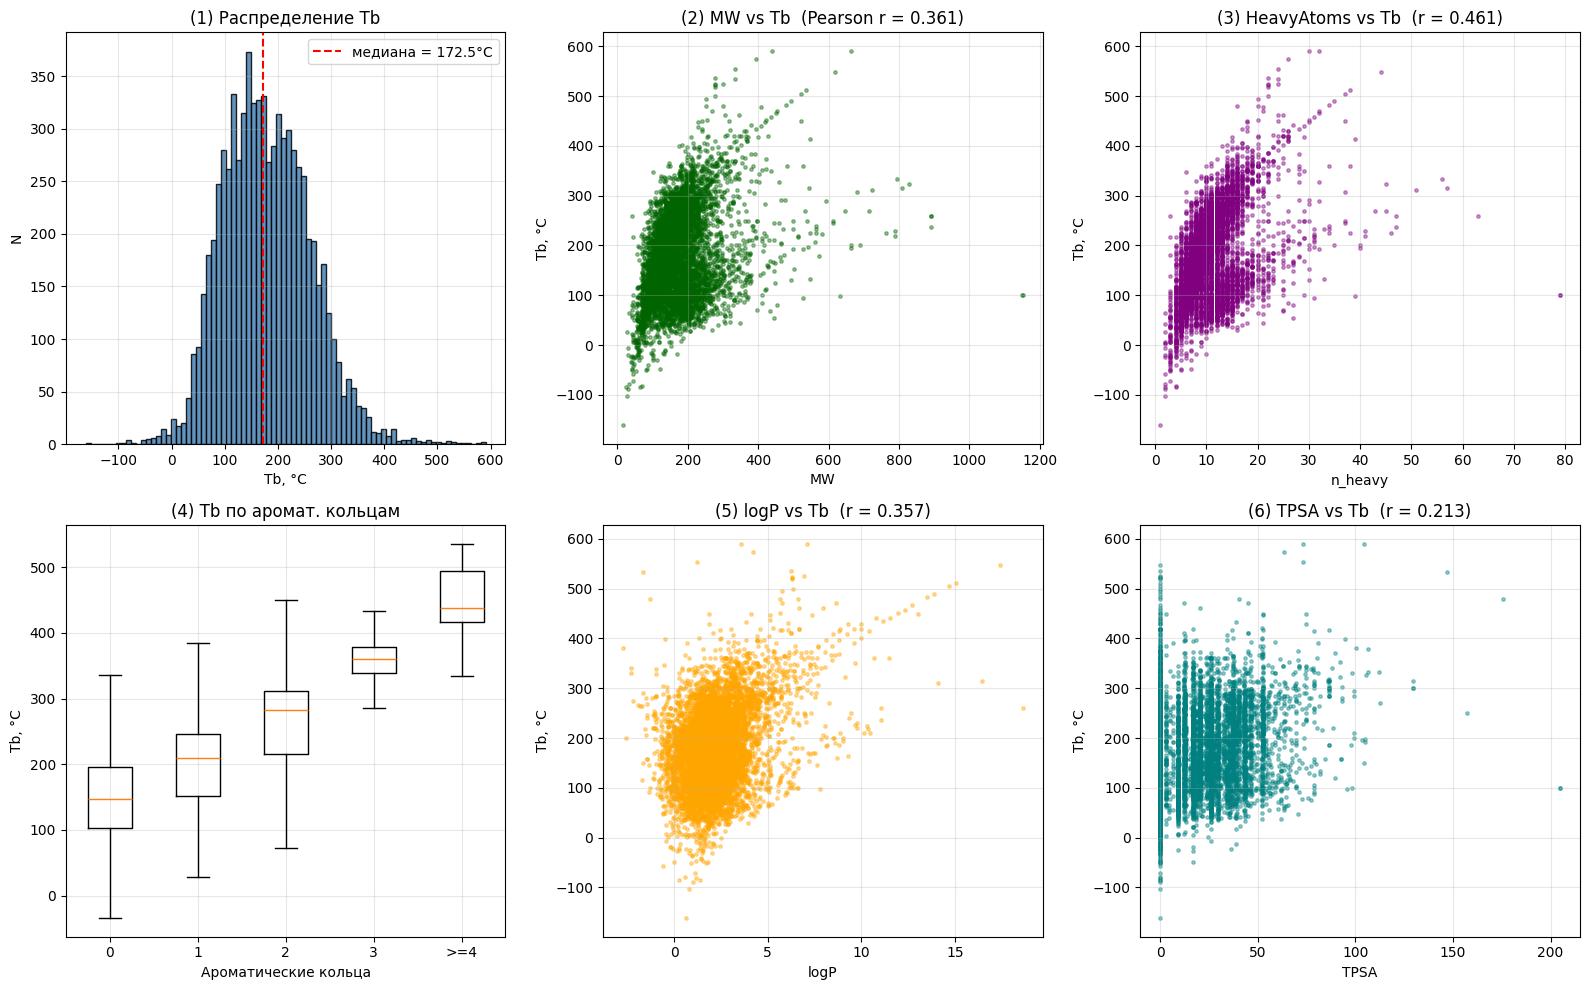

Сохранено: eda_dashboard_ochem.png


In [79]:
# EDA-2. Дашборд: 6 графиков
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ax = axes[0, 0]
ax.hist(eda["Temperature_Celsius"], bins=80, color="steelblue", edgecolor="black", alpha=0.85)
med = eda["Temperature_Celsius"].median()
ax.axvline(med, color="red", linestyle="--", label="медиана = {:.1f}°C".format(med))
ax.set_xlabel("Tb, °C"); ax.set_ylabel("N"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("(1) Распределение Tb")

ax = axes[0, 1]
ax.scatter(eda["mw"], eda["Temperature_Celsius"], s=6, alpha=0.4, color="darkgreen")
corr_mw = eda[["mw","Temperature_Celsius"]].corr().iloc[0,1]
ax.set_xlabel("MW"); ax.set_ylabel("Tb, °C")
ax.set_title("(2) MW vs Tb  (Pearson r = {:.3f})".format(corr_mw))
ax.grid(alpha=0.3)

ax = axes[0, 2]
ax.scatter(eda["n_heavy"], eda["Temperature_Celsius"], s=6, alpha=0.4, color="purple")
corr_ha = eda[["n_heavy","Temperature_Celsius"]].corr().iloc[0,1]
ax.set_xlabel("n_heavy"); ax.set_ylabel("Tb, °C")
ax.set_title("(3) HeavyAtoms vs Tb  (r = {:.3f})".format(corr_ha))
ax.grid(alpha=0.3)

ax = axes[1, 0]
arom_bin = eda["n_arom"].clip(upper=4)
groups = [eda.loc[arom_bin == k, "Temperature_Celsius"].values for k in range(5)]
ax.boxplot(groups, tick_labels=["0","1","2","3",">=4"], showfliers=False)
ax.set_xlabel("Ароматические кольца"); ax.set_ylabel("Tb, °C")
ax.set_title("(4) Tb по аромат. кольцам"); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.scatter(eda["logp"], eda["Temperature_Celsius"], s=6, alpha=0.4, color="orange")
corr_lp = eda[["logp","Temperature_Celsius"]].corr().iloc[0,1]
ax.set_xlabel("logP"); ax.set_ylabel("Tb, °C")
ax.set_title("(5) logP vs Tb  (r = {:.3f})".format(corr_lp))
ax.grid(alpha=0.3)

ax = axes[1, 2]
ax.scatter(eda["tpsa"], eda["Temperature_Celsius"], s=6, alpha=0.4, color="teal")
corr_tp = eda[["tpsa","Temperature_Celsius"]].corr().iloc[0,1]
ax.set_xlabel("TPSA"); ax.set_ylabel("Tb, °C")
ax.set_title("(6) TPSA vs Tb  (r = {:.3f})".format(corr_tp))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("eda_dashboard_ochem.png", dpi=110, bbox_inches="tight")
plt.show()
print("Сохранено: eda_dashboard_ochem.png")


In [80]:
# EDA-3. Sanity-check по InChIKey
reference = [
    ("Methane",        "C",                  -161.5),
    ("Ethane",         "CC",                  -88.6),
    ("Ethanol",        "CCO",                  78.4),
    ("Methanol",       "CO",                   64.7),
    ("Water",          "O",                   100.0),
    ("Benzene",        "c1ccccc1",             80.1),
    ("Toluene",        "Cc1ccccc1",           110.6),
    ("Acetone",        "CC(C)=O",              56.1),
    ("Diethyl ether",  "CCOCC",                34.6),
    ("n-Hexane",       "CCCCCC",               68.7),
    ("n-Heptane",      "CCCCCCC",              98.4),
    ("n-Octane",       "CCCCCCCC",            125.7),
    ("Chloroform",     "ClC(Cl)Cl",            61.2),
    ("Acetic acid",    "CC(=O)O",             118.1),
]

key2tb = {}
for _, row in eda.iterrows():
    m = Chem.MolFromSmiles(row["smiles"])
    if m is None: continue
    for a in m.GetAtoms():
        a.SetAtomMapNum(0)
    k = MolToInchiKey(m)
    if k: key2tb.setdefault(k, []).append(row["Temperature_Celsius"])

print("{:18s} {:>10s} {:>12s} {:>9s}".format("Compound","Lit. Tb","Our Tb","delta"))
print("-" * 55)
found = 0
for name, smi, lit in reference:
    m = Chem.MolFromSmiles(smi)
    k = MolToInchiKey(m)
    if k in key2tb:
        our = float(np.nanmean(key2tb[k]))
        diff = our - lit
        flag = "" if abs(diff) <= 3.0 else "  <-- расхождение"
        print("{:18s} {:>10.1f} {:>12.2f} {:>+9.2f}{}".format(name, lit, our, diff, flag))
        found += 1
    else:
        print("{:18s} {:>10.1f} {:>12s}".format(name, lit, "нет"))
print()
print("Найдено {} из {} эталонных молекул".format(found, len(reference)))


Compound              Lit. Tb       Our Tb     delta
-------------------------------------------------------
Methane                -161.5      -161.50     +0.00
Ethane                  -88.6       -88.45     +0.15
Ethanol                  78.4        78.13     -0.27
Methanol                 64.7        64.92     +0.22
Water                   100.0          нет
Benzene                  80.1        79.87     -0.23
Toluene                 110.6       110.48     -0.12
Acetone                  56.1        55.75     -0.35
Diethyl ether            34.6        34.60     +0.00
n-Hexane                 68.7        68.77     +0.07
n-Heptane                98.4        98.30     -0.10
n-Octane                125.7       125.76     +0.06
Chloroform               61.2        61.07     -0.13
Acetic acid             118.1       116.96     -1.14

Найдено 13 из 14 эталонных молекул


In [81]:
# EDA-4. Распределение элементов + поиск выбросов
from collections import Counter
elem_count = Counter()
for smi in eda["smiles"]:
    m = Chem.MolFromSmiles(smi)
    if m is None: continue
    for a in m.GetAtoms():
        elem_count[a.GetSymbol()] += 1

print("Топ-15 элементов:")
for elem, n in elem_count.most_common(15):
    print("  {:3s} {:>8d}".format(elem, n))

# Линейная модель Tb ~ MW
sub = eda.dropna(subset=["mw","Temperature_Celsius"]).copy()
x, y = sub["mw"].values, sub["Temperature_Celsius"].values
coef = np.polyfit(x, y, 1)
resid = y - np.polyval(coef, x)
sigma = float(resid.std())
sub["residual"] = resid
mask_out = np.abs(resid) > 3 * sigma

print()
print("Линейная аппроксимация: Tb ~= {:.3f}*MW + {:.1f}, sigma = {:.1f} °C".format(
    coef[0], coef[1], sigma))
print("Кандидаты в выбросы (|остаток| > 3 sigma): {} из {}".format(int(mask_out.sum()), len(sub)))

outliers = sub.loc[mask_out].copy()
outliers = outliers.reindex(outliers["residual"].abs().sort_values(ascending=False).index)
print()
print("Топ-15 выбросов:")
cols = [c for c in ["compound","CAS","mw","Temperature_Celsius","residual"] if c in outliers.columns]
print(outliers[cols].head(15).to_string(index=False))


Топ-15 элементов:
  C      61239
  O       8363
  F       3549
  N       2907
  Cl      2124
  Si       695
  S        592
  Br       579
  I        121
  P        114
  Sn        32
  B         31
  As        16
  Ge        13
  Se         8

Линейная аппроксимация: Tb ~= 0.394*MW + 112.9, sigma = 77.1 °C
Кандидаты в выбросы (|остаток| > 3 sigma): 23 из 7542

Топ-15 выбросов:
                                                                         compound         CAS       mw  Temperature_Celsius    residual
                                                                          Brij 78         nan 1151.561                100.0 -466.357946
                                                                          Brij 98         nan 1149.545                100.0 -465.564023
                                                           INDENO(1,2,3-CD)PYRENE    193-39-5  276.338                536.0  314.314430
Ethyl 3-(hydroxymethyl)-4-oxo-1-phenyl-1,3,8-triazaspiro[4,5]decane-8-carbox

## Итог

**Что получилось:**

| Файл | Содержимое |
|---|---|
| `ochem_raw_clean.sdf` | После физ. фильтра + P~1 атм, с явными H |
| `ochem_nbp_final.sdf` | После стандартизации chython |
| `ochem_nbp_stereo.sdf` | То же со стерео |
| `ochem_nbp_stereo_clean.sdf` | InChI-дедуп со стерео |
| **`ochem_nbp_final_clean.sdf`** | **Финальный файл OCHEM для слияния** |

## Стратегия дальнейшей работы

Здесь **намеренно** не делаем агрессивную чистку (никаких 3σ-фильтров, strict-фильтров и удаления «подозрительных» классов). Причины:

1. **Каждый источник по-своему «странный».** chemeo, PubChem, OCHEM имеют разный состав химии — пытаться нормализовать каждый отдельно бессмысленно.
2. **Лучшая чистка возможна только после слияния**, потому что появляется новая информация: *совпадает ли Tb в нескольких источниках?* Это в разы надёжнее, чем 3σ по одной линейной модели.
3. **Pearson r на отдельной выборке ≠ качество данных.** Sanity-check на 14 эталонных молекулах показывает идеальное совпадение с литературой (±1 °C) — этого достаточно для подтверждения корректности парсинга. Низкий Pearson r на полном OCHEM = просто эффект разнородности химии (ПАУ, перфторсоединения, металлоорганика), а не ошибки в данных.

## План объединения

```
inputs:
  chemeo_nbp_ml_ready.sdf       (~4 276) – литературные NBP
  pubchem_nbp_ml_ready_pure.sdf (~1 470) – PubChem, P~1, после 3σ
  ochem_nbp_final_clean.sdf     (~7 500) – OCHEM, P~1, после InChI-дедупа

merge:
  1. Прочитать всё в один DataFrame с пометкой source
  2. Сгруппировать по InChI:
     - если запись из одного источника → принимаем
     - если из нескольких → проверяем разброс Tb:
        * ≤ 5 °C  → усреднение (n_sources как фича доверия)
        * > 5 °C  → берём приоритетный (chemeo > ochem > pubchem) и логируем конфликт
  3. Final-фильтр на объединённом наборе:
     - выбросы по линейной модели Tb~MW + дополнительным фичам
     - phys/range проверки
     - анализ распределения по элементам/scaffold-классам

output:
  merged_nbp.sdf  (~10–13 тыс. уникальных молекул, готов для ML)
```

В таком пайплайне «плохие метки» проявятся как **межисточниковые конфликты** (Brij в OCHEM = 100 °C, а в chemeo может быть «нет данных» или другое значение), и мы можем удалить их с уверенностью.

## Метаданные в финальном SDF

Совместимый с chemeo/PubChem формат:
- `Temperature_Celsius`, `Pressure_Atm` — целевая переменная и давление (≈1)
- `InChI`, `SMILES_orig` — идентификация структуры
- `CAS`, `compound`, `RECORDID`, `ARTICLEID` — провенанс
- `source = "ochem"`
- `measurement_type = "normal_bp"`
- `n_measurements` — сколько литературных измерений усреднено
